<a href="https://colab.research.google.com/github/Addreta/ctqw-mott-probe/blob/main/ctqw_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install quspin

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.5/38.5 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.9 MB/s eta 0:00:00
  Created wheel for importlib: filename=importlib-1.0.4-py3-none-any.whl size=5850 sha256=85dde66c084e5d17a78b49127e3b1bd41471f63fb37d901c36599e64a0274c31
  Stored in directory: /root/.cache/pip/wheels/40/41/c4/d925a53b7b7e75a65369e1b17f7bade00d7907ac5a7d74dc5f
Successfully built importlib


In [2]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

def compute_obdm(psi_gs, basis, L):
    obdm = np.zeros((L, L), dtype=float)
    for i in range(L):
        for j in range(L):
            # spin-up: c†_i↑ c_j↑
            op_up = hamiltonian(
                [["+-|", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False
            )
            # spin-down: c†_i↓ c_j↓
            op_dn = hamiltonian(
                [["|+-", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False
            )
            obdm[i, j] = (op_up.matrix_ele(psi_gs, psi_gs) +
                          op_dn.matrix_ele(psi_gs, psi_gs)).real
    return obdm

# ED first
L = 6
N_up, N_dn = 3, 3
t_hop = 1.0
U = 4.0

basis = spinful_fermion_basis_1d(L, Nf=(N_up, N_dn))

hop_right = [[-t_hop, i, i+1] for i in range(L-1)]
hop_left  = [[+t_hop, i, i+1] for i in range(L-1)]
inter_list = [[U, i, i] for i in range(L)]

static = [
    ["+-|", hop_right], ["-+|", hop_left],
    ["|+-", hop_right], ["|-+", hop_left],
    ["n|n", inter_list]
]

H = hamiltonian(static, [], basis=basis, dtype=np.float64)
E, V = H.eigh()
psi_gs = V[:, 0]

obdm = compute_obdm(psi_gs, basis, L)
np.set_printoptions(precision=4, suppress=True)
print(obdm)

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conservation check passed!
Particle conse

In [3]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

# ── parameters ──────────────────────────────────────────────
L     = 6
N_up  = 3
N_dn  = 3
t_hop = 1.0
U     = 4.0

# ── basis ────────────────────────────────────────────────────
basis = spinful_fermion_basis_1d(L, Nf=(N_up, N_dn))

# ── Hamiltonian ──────────────────────────────────────────────
hop_right  = [[-t_hop, i, i+1] for i in range(L-1)]
hop_left   = [[+t_hop, i, i+1] for i in range(L-1)]
inter_list = [[U, i, i]         for i in range(L)]

static = [
    ["+-|", hop_right], ["-+|", hop_left],
    ["|+-", hop_right], ["|-+", hop_left],
    ["n|n", inter_list]
]

H = hamiltonian(static, [], basis=basis, dtype=np.float64,
                check_symm=False, check_herm=False, check_pcon=False)

E, V   = H.eigh()
psi_gs = V[:, 0]
print(f"Ground state energy: {E[0]:.6f}")

# ── OBDM ─────────────────────────────────────────────────────
def compute_obdm(psi_gs, basis, L):
    obdm = np.zeros((L, L), dtype=float)
    for i in range(L):
        for j in range(L):
            op_up = hamiltonian(
                [["+-|", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False, check_pcon=False
            )
            op_dn = hamiltonian(
                [["|+-", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False, check_pcon=False
            )
            obdm[i, j] = (op_up.matrix_ele(psi_gs, psi_gs) +
                          op_dn.matrix_ele(psi_gs, psi_gs)).real
    return obdm

obdm = compute_obdm(psi_gs, basis, L)
np.set_printoptions(precision=4, suppress=True)
print(obdm)

# ── CTQW functions ───────────────────────────────────────────
def ctqw_centrality(A):
    L          = A.shape[0]
    eigs, V    = np.linalg.eigh(A)
    psi0       = np.ones(L) / np.sqrt(L)
    c_k        = V.T @ psi0
    pi         = np.einsum('jk,k->j', V**2, c_k**2)
    return pi

def spectral_gap(A):
    eigs = np.sort(np.linalg.eigvalsh(A))
    return eigs[-1] - eigs[-2]

def classical_eigenvector_centrality(A):
    eigs, vecs = np.linalg.eigh(A)
    return np.abs(vecs[:, -1])

# ── U/t sweep ────────────────────────────────────────────────
U_over_t_values = np.array([0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 16.0])
results = []

for U_t in U_over_t_values:
    U      = U_t * t_hop
    basis  = spinful_fermion_basis_1d(L, Nf=(N_up, N_dn))

    inter_list = [[U, i, i] for i in range(L)]
    static = [
        ["+-|", hop_right], ["-+|", hop_left],
        ["|+-", hop_right], ["|-+", hop_left],
        ["n|n", inter_list]
    ]

    H      = hamiltonian(static, [], basis=basis, dtype=np.float64,
                         check_symm=False, check_herm=False, check_pcon=False)
    E, V   = H.eigh()
    psi_gs = V[:, 0]

    rho  = compute_obdm(psi_gs, basis, L)
    pi   = ctqw_centrality(rho)
    gap  = spectral_gap(rho)
    ec   = classical_eigenvector_centrality(rho)

    results.append({
        'U_t'             : U_t,
        'obdm'            : rho,
        'ctqw_centrality' : pi,
        'spectral_gap'    : gap,
        'classical_ec'    : ec,
    })
    print(f"U/t = {U_t:5.1f} | gap = {gap:.4f} | E0 = {E[0]:.4f}")

Ground state energy: -3.092565
[[ 1.      0.6457  0.     -0.163  -0.      0.0702]
 [ 0.6457  1.      0.3637 -0.     -0.0392  0.    ]
 [ 0.      0.3637  1.      0.603   0.     -0.163 ]
 [-0.163  -0.      0.603   1.      0.3637 -0.    ]
 [-0.     -0.0392  0.      0.3637  1.      0.6457]
 [ 0.0702  0.     -0.163  -0.      0.6457  1.    ]]
U/t =   0.5 | gap = 0.0018 | E0 = -6.2732
U/t =   1.0 | gap = 0.0071 | E0 = -5.6289
U/t =   2.0 | gap = 0.0262 | E0 = -4.5463
U/t =   4.0 | gap = 0.0704 | E0 = -3.0926
U/t =   6.0 | gap = 0.0904 | E0 = -2.2667
U/t =   8.0 | gap = 0.0916 | E0 = -1.7681
U/t =  12.0 | gap = 0.0784 | E0 = -1.2154
U/t =  16.0 | gap = 0.0648 | E0 = -0.9219


In [4]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

# ── parameters ──────────────────────────────────────────────
L     = 6
N_up  = 3
N_dn  = 3
t_hop = 1.0

# ── OBDM ────────────────────────────────────────────────────
def compute_obdm(psi_gs, basis, L):
    """
    rho_ij = <GS| c†_i↑ c_j↑ + c†_i↓ c_j↓ |GS>
    """
    obdm = np.zeros((L, L), dtype=float)
    for i in range(L):
        for j in range(L):
            op_up = hamiltonian(
                [["+-|", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False, check_pcon=False
            )
            op_dn = hamiltonian(
                [["|+-", [[1.0, i, j]]]],
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False, check_pcon=False
            )
            obdm[i, j] = (op_up.matrix_ele(psi_gs, psi_gs) +
                          op_dn.matrix_ele(psi_gs, psi_gs)).real
    return obdm

# ── CTQW functions ───────────────────────────────────────────
def ctqw_centrality(A):
    """
    Long-time averaged occupation probability.
    pi_j = sum_k |V_jk|^2 |c_k|^2
    Initial state: uniform superposition.
    Normalized: sum_j pi_j = 1
    """
    L       = A.shape[0]
    _, V    = np.linalg.eigh(A)
    psi0    = np.ones(L) / np.sqrt(L)
    c_k     = V.T @ psi0
    pi      = np.einsum('jk,k->j', V**2, c_k**2)
    return pi

def spectral_gap(A):
    """
    Gap between two largest eigenvalues of OBDM graph.
    Peaks non-monotonically at Mott crossover.
    """
    eigs = np.sort(np.linalg.eigvalsh(A))
    return eigs[-1] - eigs[-2]

def classical_eigenvector_centrality(A):
    """
    Leading eigenvector of OBDM.
    Not normalized here — normalize at plot time via ec/ec.sum()
    """
    _, vecs = np.linalg.eigh(A)
    return np.abs(vecs[:, -1])

# ── U/t sweep ────────────────────────────────────────────────
U_over_t_values = np.array([0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 16.0])
results = []

for U_t in U_over_t_values:
    U = U_t * t_hop

    basis = spinful_fermion_basis_1d(L, Nf=(N_up, N_dn))

    # hopping and interaction (redefined each iteration for clarity)
    hop_right  = [[-t_hop, i, i+1] for i in range(L-1)]
    hop_left   = [[+t_hop, i, i+1] for i in range(L-1)]
    inter_list = [[U,      i, i  ] for i in range(L)]

    static = [
        ["+-|", hop_right], ["-+|", hop_left],   # spin-up hopping
        ["|+-", hop_right], ["|-+", hop_left],   # spin-down hopping
        ["n|n", inter_list]                       # Hubbard U
    ]

    H = hamiltonian(static, [], basis=basis, dtype=np.float64,
                    check_symm=False, check_herm=False, check_pcon=False)

    E, V   = H.eigh()
    psi_gs = V[:, 0]

    rho = compute_obdm(psi_gs, basis, L)
    pi  = ctqw_centrality(rho)
    gap = spectral_gap(rho)
    ec  = classical_eigenvector_centrality(rho)

    results.append({
        'U_t'             : U_t,
        'obdm'            : rho,
        'ctqw_centrality' : pi,
        'spectral_gap'    : gap,
        'classical_ec'    : ec,
        'ground_energy'   : E[0]
    })

    print(f"U/t = {U_t:5.1f} | gap = {gap:.4f} | E0 = {E[0]:.4f}")

print("Done.")

U/t =   0.5 | gap = 0.0018 | E0 = -6.2732
U/t =   1.0 | gap = 0.0071 | E0 = -5.6289
U/t =   2.0 | gap = 0.0262 | E0 = -4.5463
U/t =   4.0 | gap = 0.0704 | E0 = -3.0926
U/t =   6.0 | gap = 0.0904 | E0 = -2.2667
U/t =   8.0 | gap = 0.0916 | E0 = -1.7681
U/t =  12.0 | gap = 0.0784 | E0 = -1.2154
U/t =  16.0 | gap = 0.0648 | E0 = -0.9219
Done.


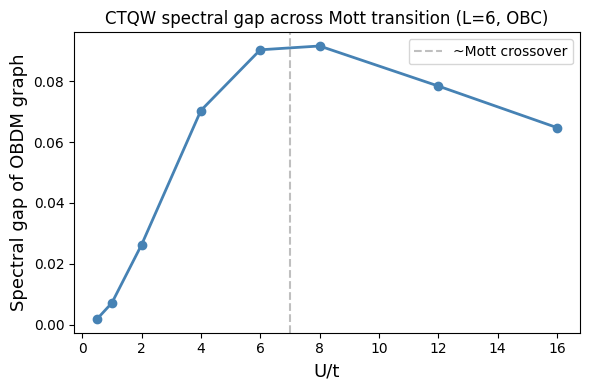

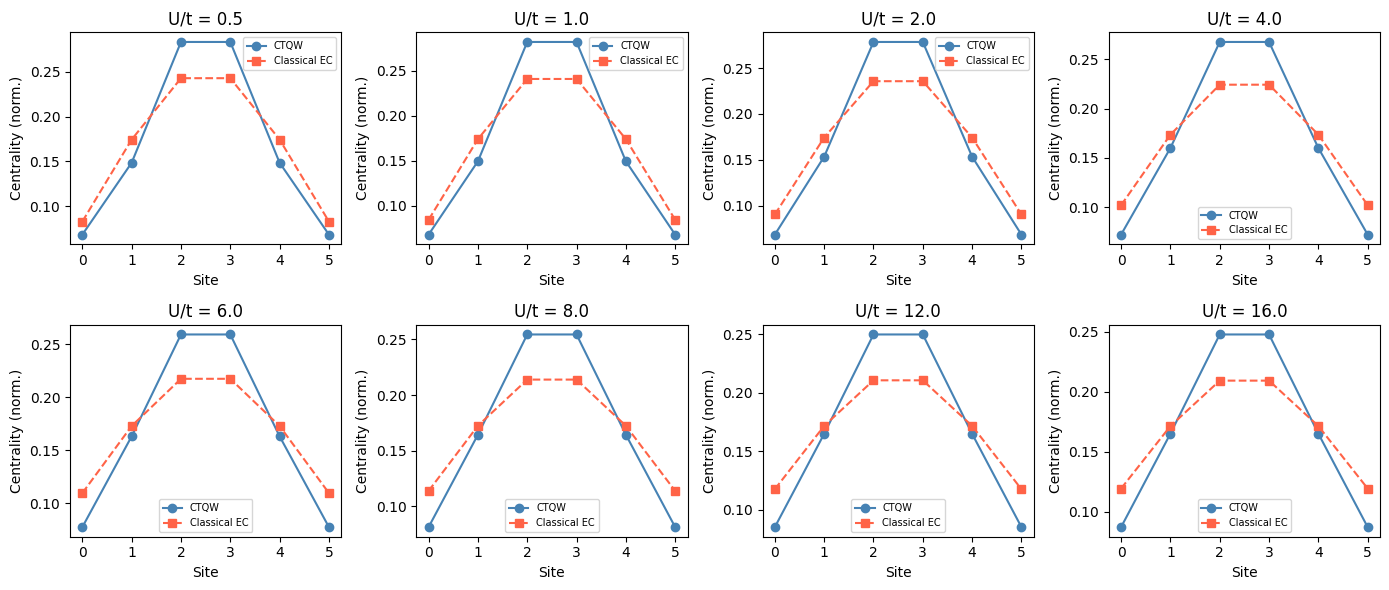

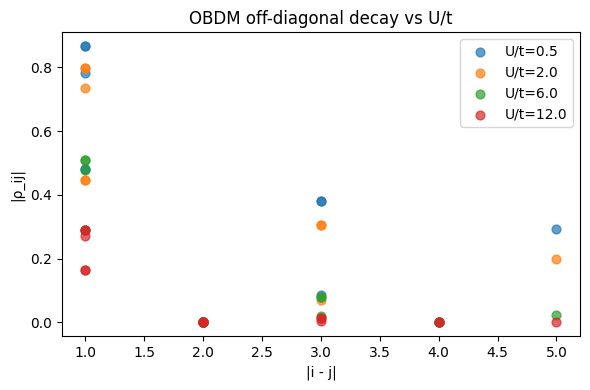

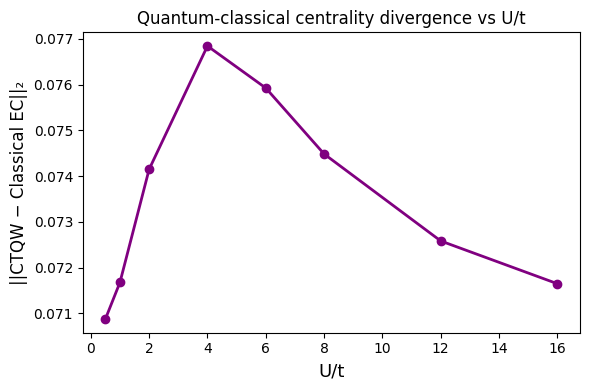

In [5]:
import matplotlib.pyplot as plt

sites  = np.arange(L)
U_ts   = [r['U_t'] for r in results]
gaps   = [r['spectral_gap'] for r in results]

# ── Plot 1: Spectral gap ─────────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(U_ts, gaps, 'o-', color='steelblue', linewidth=2)
plt.axvline(x=7, linestyle='--', color='gray', alpha=0.5, label='~Mott crossover')
plt.xlabel("U/t", fontsize=13)
plt.ylabel("Spectral gap of OBDM graph", fontsize=13)
plt.title("CTQW spectral gap across Mott transition (L=6, OBC)")
plt.legend()
plt.tight_layout()
plt.savefig("spectral_gap.png", dpi=150)
plt.show()

# ── Plot 2: Centrality profiles ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
for ax, r in zip(axes.flat, results):
    pi = r['ctqw_centrality']
    ec = r['classical_ec'] / r['classical_ec'].sum()
    ax.plot(sites, pi, 'o-', color='steelblue', label='CTQW')
    ax.plot(sites, ec, 's--', color='tomato',   label='Classical EC')
    ax.set_title(f"U/t = {r['U_t']}")
    ax.set_xlabel("Site")
    ax.set_ylabel("Centrality (norm.)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("centrality_profiles.png", dpi=150)
plt.show()

# ── Plot 3: OBDM off-diagonal decay ──────────────────────────
fig, ax = plt.subplots(figsize=(6,4))
for r in results[::2]:
    rho = r['obdm']
    distances, elements = [], []
    for i in range(L):
        for j in range(i+1, L):
            distances.append(abs(i-j))
            elements.append(abs(rho[i,j]))
    ax.scatter(distances, elements, label=f"U/t={r['U_t']}", alpha=0.7, s=40)
ax.set_xlabel("|i - j|")
ax.set_ylabel("|ρ_ij|")
ax.set_title("OBDM off-diagonal decay vs U/t")
ax.legend()
plt.tight_layout()
plt.savefig("obdm_decay.png", dpi=150)
plt.show()

# ── Plot 4: Quantum-classical divergence ─────────────────────
from scipy.spatial.distance import euclidean
divergences = []
for r in results:
    pi = r['ctqw_centrality']
    ec = r['classical_ec'] / r['classical_ec'].sum()
    divergences.append(euclidean(pi, ec))

plt.figure(figsize=(6,4))
plt.plot(U_ts, divergences, 'o-', color='purple', linewidth=2)
plt.xlabel("U/t", fontsize=13)
plt.ylabel("||CTQW − Classical EC||₂", fontsize=12)
plt.title("Quantum-classical centrality divergence vs U/t")
plt.tight_layout()
plt.savefig("centrality_divergence.png", dpi=150)
plt.show()